# Standalone signal-quality / artifact-context preprocessing branch

**Correct name and scope.** The implemented branch returns continuous
signal-quality indices, per-feature availability booleans, and explicit
reasons when prerequisites are missing. It is **not yet an artifact
classifier** and does not emit a universal clean/artifact decision.

The notebook covers finite samples, saturation, flatline, ADC rails,
amplitude, baseline/QRS-band power, skewness/kurtosis, high-frequency
noise, bSQI, qSQI, Ho RR support, cross-lead iSQI, beat-template
correlation, Galeotti baseline/mains/residual features, Menon Fourier
score, trailing causal windows, and controlled degradations.

It demonstrates how measurements respond to synthetic corruption but
intentionally does not turn that response into a trained threshold.

## 1. Reproducible environment and data selection

This notebook is **independent of the other notebooks**. It locates the
project, imports the installed/tested branch package, selects one ECG
channel explicitly, creates its own output directory, and records the
runtime versions. The executable example uses MIT–BIH record 100,
channel `MLII`, starting at 0 s for 60 s.

Change only the configuration cell below to use another WFDB record.
For EDF data, use `ecg_cascade.edf.load_ecg_segment` after explicitly
inspecting and choosing the ECG channel.

#### Code walkthrough — imports, project discovery, and frozen run configuration

        **Why this cell exists.** Every later result depends on using the intended package, dataset, lead, units, and output folder.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Imports | Loads hashing, tables, numerical methods, plotting, NeuroKit, WFDB, and notebook display helpers. | The notebook needs both computation and visible audit evidence. |
| 2 | Project discovery | Searches the current directory and its parents for `pyproject.toml` and `src/ecg_cascade`, then places `src` on `sys.path`. | The same notebook must run from the repository root or its own folder without importing an unrelated installed copy. |
| 3 | Output contract | Creates one branch-specific directory under `outputs/standalone_notebooks`. | CSV, JSON, and manifests remain separate and reproducible. |
| 4 | Input configuration | Freezes record 100, lead MLII, start, duration, and patient identifier; the header assertion fails early if data are missing. | A clinical reader must know exactly which signal produced the figures. |
| 5 | Display configuration | Applies a consistent plot style and wide table display. | Successful runs should be readable without hidden columns or default styling ambiguity. |
| 6 | Version printout | Prints Python and dependency versions plus resolved paths. | A future rerun can distinguish data or code changes from environment changes. |

        **Evidence that the cell ran correctly**

        - A compact version block is printed with Python, NumPy, pandas, SciPy, NeuroKit2, and WFDB versions.
- `Project` resolves to the repository's `feature_extraction` folder and `Output` resolves to this branch's folder.
- No import, missing-file, or path assertion error appears.

        **If that evidence is absent, investigate**

        - A wrong working directory or a missing `feature_extraction/pyproject.toml`.
- The MIT–BIH dataset path or the requested lead name.
- A notebook kernel that is not using the project virtual environment.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [1]:
from pathlib import Path
import hashlib
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import neurokit2 as nk
import wfdb
from IPython.display import Code, Markdown, display

# Locate feature_extraction regardless of whether execution starts from
# the repository root, feature_extraction, or the notebook directory.
search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
PROJECT = next(
    path for path in search_roots
    if (path / "pyproject.toml").is_file()
    and (path / "src" / "ecg_cascade").is_dir()
)
ROOT = PROJECT.parent
SRC = PROJECT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

OUTPUT_DIR = PROJECT / "outputs" / "standalone_notebooks" / "signal_quality"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DEMO_RECORD = (
    ROOT / "Datasets" / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0" / "100"
)
assert DEMO_RECORD.with_suffix(".hea").is_file(), DEMO_RECORD

RECORD_PATH = DEMO_RECORD       # WFDB path without extension
CHANNEL = "MLII"                # explicit lead choice
START_S = 0.0
DURATION_S = 60.0
PATIENT_ID = "mitdb_100"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 4.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelcolor": "#304955",
    "text.color": "#203845",
})
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

print("Python:", platform.python_version())
print("NumPy:", np.__version__, "Pandas:", pd.__version__, "SciPy:", scipy.__version__)
print("NeuroKit2:", nk.__version__, "WFDB:", wfdb.__version__)
print("Project:", PROJECT)
print("Output:", OUTPUT_DIR)

Python: 3.12.10
NumPy: 2.4.2 Pandas: 2.3.3 SciPy: 1.17.0
NeuroKit2: 0.2.13 WFDB: 4.3.1
Project: C:\Users\Salam\Documents\ECGdetector\feature_extraction
Output: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\signal_quality


#### Code walkthrough — load, validate, summarize, and preview the input ECG

        **Why this cell exists.** Algorithm outputs are interpretable only after the waveform, sampling rate, time coordinates, units, and finite-sample checks are visible.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Loader import | Imports the project's WFDB segment loader. | This centralizes channel lookup and physical-unit conversion instead of duplicating raw WFDB calls. |
| 2 | Segment read | Loads the configured lead and time range, then extracts samples and sampling frequency. | Every sample index used later must map to a physical time. |
| 3 | Time axis | Builds an absolute time vector from the segment start and sample rate. | Plots and event tables then share the same coordinate system. |
| 4 | Assertions | Requires one-dimensional, finite data and at least three seconds of signal. | Downstream filters and interval calculations should fail visibly rather than accept malformed input. |
| 5 | Summary | Prints source, lead, sampling rate, sample count, time span, and amplitude range. | This is the run's input provenance and first unit sanity check. |
| 6 | Preview figure | Plots the first 12 seconds of the unmodified physical ECG. | A reviewer can see polarity, gain, baseline, and recognizable beats before any branch operates. |

        **Evidence that the cell ran correctly**

        - The summary reports 360 Hz, the requested duration, finite amplitude limits, and channel MLII.
- The figure shows a continuous ECG trace with no blank panel or clipped time axis.
- The x-axis is seconds and the y-axis explicitly says physical WFDB units.

        **If that evidence is absent, investigate**

        - Lead selection, start/duration bounds, or a corrupt/missing WFDB pair.
- NaN/Inf samples, an unexpectedly flat trace, or an amplitude scale inconsistent with the header.
- A wrong sampling rate, because every millisecond conversion below depends on it.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

{'source': 'C:\\Users\\Salam\\Documents\\ECGdetector\\Datasets\\mit-bih-arrhythmia-database-1.0\\mit-bih-arrhythmia-database-1.0.0\\100', 'channel': 'MLII', 'sampling_rate_hz': 360.0, 'samples': 21600, 'start_s': 0.0, 'duration_s': 60.0, 'minimum': -0.695, 'maximum': 1.05}


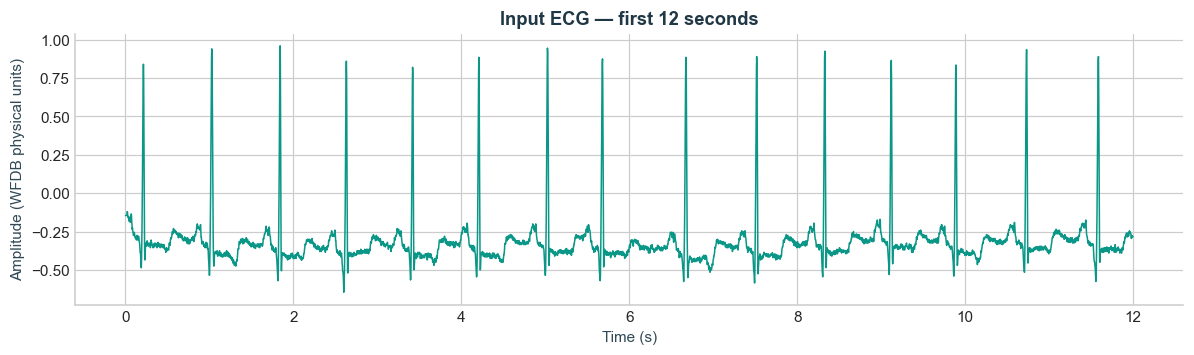

In [2]:
from ecg_cascade.wfdb_io import load_wfdb_segment

segment = load_wfdb_segment(
    RECORD_PATH,
    channel=CHANNEL,
    start_s=START_S,
    duration_s=DURATION_S,
)
ecg = segment.samples
fs = float(segment.sampling_rate_hz)
time_s = segment.start_s + np.arange(ecg.size) / fs

assert ecg.ndim == 1
assert np.all(np.isfinite(ecg))
assert ecg.size >= int(3 * fs)
print({
    "source": segment.record_path,
    "channel": segment.channel_name,
    "sampling_rate_hz": fs,
    "samples": int(ecg.size),
    "start_s": segment.start_s,
    "duration_s": segment.duration_s,
    "minimum": float(ecg.min()),
    "maximum": float(ecg.max()),
})

preview = time_s < time_s[0] + 12
fig, ax = plt.subplots(figsize=(13, 3.2))
ax.plot(time_s[preview], ecg[preview], color="#0b9787", lw=1.0)
ax.set(title="Input ECG — first 12 seconds", xlabel="Time (s)", ylabel="Amplitude (WFDB physical units)")
plt.show()

### Reproducibility rules used throughout

- No missing-sample imputation is performed.
- The selected channel and physical-unit scale are shown explicitly.
- Detector disagreement is context, not ground truth or artifact.
- All rolling windows are trailing/causal where the implementation says so.
- No notebook cell trains a seizure classifier or produces a clinical label.
- Tables are exported separately so intermediate measurements remain auditable.

## 2. Unit declaration and prerequisite signals

MIT–BIH physical signals are stored in mV, so amplitude-valued SQIs are
converted with `uv_per_input_unit=1000`. The value must be changed for a
source stored in volts, µV, or ADC counts. The second `V5` channel is
loaded only to demonstrate cross-lead agreement; it is not averaged with
`MLII`.

#### Code walkthrough — declare units and construct every SQI prerequisite

        **Why this cell exists.** Amplitude SQIs, cross-lead agreement, detector agreement, and baseline estimates are meaningless if their units and event sources are implicit.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Header audit | Reads WFDB channel names/units and requires MLII to be stored in mV. | The following µV conversion must match metadata. |
| 2 | Unit/mains constants | Sets 1000 µV per input unit and an explicit 60-Hz demo assumption. | Amplitude and powerline features need physical metadata. |
| 3 | Second lead | Loads synchronized V5 with matching rate and length. | Cross-lead iSQI compares events; it does not average waveforms. |
| 4 | Detector pair | Creates NeuroKit and Zhai event arrays on MLII and NeuroKit events on V5. | bSQI/qSQI/iSQI require named, independent inputs. |
| 5 | QRS onsets | Runs prominence delineation and retains finite integer onset samples. | Galeotti baseline anchors require QRS timing. |
| 6 | Count print | Reports prerequisite event availability. | Missing inputs are visible before the SQI table. |

        **Evidence that the cell ran correctly**

        - Header units print MLII/V5 as mV and all four event counts are positive.
- The synchronization assertions pass.

        **If that evidence is absent, investigate**

        - A dataset stored in V, µV, or ADC counts—change the conversion explicitly.
- Wrong mains-region metadata.
- Unsynchronized lead segments or missing QRS onset landmarks.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [3]:
from ecg_cascade import NeuroKitZhaiConfig, run_neurokit_zhai_array
from ecg_cascade.peaks import detect_r_peaks
from ecg_cascade.prominence_morphology import extract_prominence_morphology

header = wfdb.rdheader(str(RECORD_PATH))
channel_index = header.sig_name.index(CHANNEL)
print("WFDB header units:", dict(zip(header.sig_name, header.units)))
assert header.units[channel_index].casefold() == "mv"
UV_PER_INPUT_UNIT = 1000.0
MAINS_FREQUENCY_HZ = 60.0  # explicit metadata assumption for MIT–BIH demo

second = load_wfdb_segment(RECORD_PATH, channel="V5", start_s=START_S, duration_s=DURATION_S)
assert second.sampling_rate_hz == fs and second.samples.size == ecg.size

cascade = run_neurokit_zhai_array(
    ecg, fs, config=NeuroKitZhaiConfig(compute_inverted_context=False)
)
primary_peaks = cascade.selected.neurokit.detector.peak_samples
secondary_peaks = cascade.selected.zhai.detector.peak_samples
other_lead_peaks = detect_r_peaks(second.samples, fs, method="neurokit").peak_samples
pqrst = extract_prominence_morphology(
    ecg, primary_peaks, fs,
    anchor_track="neurokit", patient_id=PATIENT_ID, lead_name=CHANNEL,
)
qrs_onsets = pqrst.landmarks["qrs_onset"]
qrs_onsets = np.rint(qrs_onsets[np.isfinite(qrs_onsets)]).astype(np.int64)
print({"primary_peaks": len(primary_peaks), "secondary_peaks": len(secondary_peaks),
       "other_lead_peaks": len(other_lead_peaks), "qrs_onsets": len(qrs_onsets)})

WFDB header units: {'MLII': 'mV', 'V5': 'mV'}


{'primary_peaks': 74, 'secondary_peaks': 74, 'other_lead_peaks': 73, 'qrs_onsets': 74}


## 3. Calculate the complete paper-named feature vector for one 10-second window

#### Code walkthrough — declare units and construct every SQI prerequisite

        **Why this cell exists.** Amplitude SQIs, cross-lead agreement, detector agreement, and baseline estimates are meaningless if their units and event sources are implicit.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Header audit | Reads WFDB channel names/units and requires MLII to be stored in mV. | The following µV conversion must match metadata. |
| 2 | Unit/mains constants | Sets 1000 µV per input unit and an explicit 60-Hz demo assumption. | Amplitude and powerline features need physical metadata. |
| 3 | Second lead | Loads synchronized V5 with matching rate and length. | Cross-lead iSQI compares events; it does not average waveforms. |
| 4 | Detector pair | Creates NeuroKit and Zhai event arrays on MLII and NeuroKit events on V5. | bSQI/qSQI/iSQI require named, independent inputs. |
| 5 | QRS onsets | Runs prominence delineation and retains finite integer onset samples. | Galeotti baseline anchors require QRS timing. |
| 6 | Count print | Reports prerequisite event availability. | Missing inputs are visible before the SQI table. |

        **Evidence that the cell ran correctly**

        - Header units print MLII/V5 as mV and all four event counts are positive.
- The synchronization assertions pass.

        **If that evidence is absent, investigate**

        - A dataset stored in V, µV, or ADC counts—change the conversion explicitly.
- Wrong mains-region metadata.
- Unsynchronized lead segments or missing QRS onset landmarks.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [4]:
from ecg_cascade.signal_quality import extract_signal_quality_window

first = int(20 * fs)
last = int(30 * fs)
window = ecg[first:last]

def local_events(events, start, stop):
    events = np.asarray(events, dtype=np.int64)
    keep = (events >= start) & (events < stop)
    return events[keep] - start

clean_quality = extract_signal_quality_window(
    window, fs,
    uv_per_input_unit=UV_PER_INPUT_UNIT,
    primary_peak_samples=local_events(primary_peaks, first, last),
    secondary_peak_samples=local_events(secondary_peaks, first, last),
    qrs_onset_samples=local_events(qrs_onsets, first, last),
    other_lead_peak_samples=[local_events(other_lead_peaks, first, last)],
    mains_frequency_hz=MAINS_FREQUENCY_HZ,
    flat_tolerance_input_units=0.0,
)
quality_table = pd.DataFrame({
    "value": clean_quality.values,
    "available": clean_quality.available,
    "reason": clean_quality.reasons,
})
display(quality_table)
print("Available:", int(quality_table.available.sum()), "/", len(quality_table))

,value,available,reason
finite_fraction,1.000000e+00,True,calculated
absmax_uv,1.050000e+03,True,calculated
peak_to_peak_uv,1.730000e+03,True,calculated
rms_uv,4.091449e+02,True,calculated
saturation_fraction_langley2011,0.000000e+00,True,calculated
longest_saturation_run_s_langley2011,0.000000e+00,True,calculated
flat_fraction,0.000000e+00,True,calculated
longest_flat_run_s,0.000000e+00,True,calculated
rail_fraction,NaN,False,adc_rail_metadata_missing
longest_rail_run_s,NaN,False,adc_rail_metadata_missing


Available: 26 / 31


## 4. Meaning of the major SQI families

- **Basic integrity:** finite fraction, flat runs, saturation, rails.
- **Amplitude:** absolute maximum, peak-to-peak, RMS in µV.
- **Spectral:** \(basSQI=1-P_{0-1}/P_{0-40}\),
  \(pSQI=P_{5-15}/P_{5-40}\), and Li's QRS power ratio.
- **Statistics:** population skewness and Pearson kurtosis.
- **Detector agreement:** Li bSQI Jaccard at 150 ms, Zhao/Kristof
  qSQI Dice at 75 ms, and Ho endpoint RR support at 150 ms. These
  equations are intentionally distinct.
- **Cross-lead context:** maximum same-detector Jaccard agreement.
- **Waveform consistency:** Orphanidou template correlation and Menon
  Fourier score.
- **Noise decomposition:** explicit-metadata Galeotti baseline and mains
  RMS; residual RMS requires externally supplied beat groups.

Missing prerequisites remain visible in the `available` and `reason`
columns rather than being silently imputed.

## 5. Controlled degradations — diagnostic response, not classification

#### Code walkthrough — create controlled degradations and recompute SQIs

        **Why this cell exists.** A teaching notebook should show how each measurement responds before anyone proposes a classifier or threshold.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Deterministic variants | Creates clean, baseline-wander, high-frequency-noise, flatline, and clipped copies; the random generator has a fixed seed. | Each corruption has a known mechanism and reproducible waveform. |
| 2 | Detector helper | Runs NeuroKit and Zhai afresh on each variant. | Detector-agreement SQIs should respond to the degraded signal, not stale clean events. |
| 3 | Quality loop | Extracts the same feature schema for every condition. | Only the waveform condition changes. |
| 4 | Comparison table | Selects integrity, spectral, agreement, and template metrics. | The PI sees complementary response types rather than one magic score. |

        **Evidence that the cell ran correctly**

        - Five condition rows appear with the same metric columns.
- Flatline fraction rises for the flatline variant and amplitude limits change for clipping.

        **If that evidence is absent, investigate**

        - Random noise without a fixed seed.
- Reusing clean detector peaks on degraded signals.
- Calling the most responsive metric a validated artifact classifier.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [5]:
from ecg_cascade.peaks import detect_neurokit_gradient
from ecg_cascade.zhai import detect_zhai_template

local_t = np.arange(window.size) / fs
rng = np.random.default_rng(20260820)
variants = {
    "clean": window.copy(),
    "baseline_wander": window + 0.60 * np.sin(2 * np.pi * 0.30 * local_t),
    "high_frequency": window + 0.10 * np.sin(2 * np.pi * 45.0 * local_t) + 0.025 * rng.normal(size=window.size),
    "flatline_2s": window.copy(),
    "amplitude_clipped": np.clip(window, -0.45, 0.45),
}
variants["flatline_2s"][int(4 * fs):int(6 * fs)] = variants["flatline_2s"][int(4 * fs)]

def detector_pair(signal):
    nk_run = detect_neurokit_gradient(
        signal, fs, orientation="original",
        minimum_delay_ms=300.0, minimum_delay_inclusive=False,
    )
    zhai_run = detect_zhai_template(signal, fs, orientation="original")
    return nk_run.peak_samples, zhai_run.detector.peak_samples

comparison_records = []
comparison_results = {}
for name, signal in variants.items():
    p1, p2 = detector_pair(signal)
    result = extract_signal_quality_window(
        signal, fs,
        uv_per_input_unit=UV_PER_INPUT_UNIT,
        primary_peak_samples=p1,
        secondary_peak_samples=p2,
        mains_frequency_hz=MAINS_FREQUENCY_HZ,
        flat_tolerance_input_units=0.0,
    )
    comparison_results[name] = result
    comparison_records.append({"condition": name, **result.values})
degradation = pd.DataFrame(comparison_records).set_index("condition")
selected_metrics = [
    "finite_fraction", "peak_to_peak_uv", "flat_fraction", "bassqi_clifford",
    "psqi_clifford", "hf_rms_uv", "pearson_kurtosis",
    "bsqi_li2008_jaccard_150ms", "qsqi_zhao2018_dice_75ms",
    "rr_support_ho2024_150ms", "template_corr_orphanidou",
]
display(degradation[selected_metrics])

,finite_fraction,peak_to_peak_uv,flat_fraction,bassqi_clifford,psqi_clifford,hf_rms_uv,pearson_kurtosis,bsqi_li2008_jaccard_150ms,qsqi_zhao2018_dice_75ms,rr_support_ho2024_150ms,template_corr_orphanidou
condition,,,,,,,,,,,
clean,1.0,1730.000000,0.0,0.976336,0.516025,20.089774,30.944515,1.0,1.0,1.0,0.985300
baseline_wander,1.0,2765.115119,0.0,0.124524,0.516025,20.089858,2.467701,1.0,1.0,1.0,0.696353
high_frequency,1.0,1875.187753,0.0,0.975611,0.516525,67.013400,22.523158,1.0,1.0,1.0,0.917908
flatline_2s,1.0,1715.000000,0.2,0.931033,0.519721,18.744936,34.075990,1.0,1.0,1.0,0.979252
amplitude_clipped,1.0,900.000000,0.0,0.979022,0.584135,19.097563,24.557883,1.0,1.0,1.0,0.978988


#### Code walkthrough — render waveform and relative-SQI response screenshots

        **Why this cell exists.** The first plot shows what was changed; the second shows how differently scaled metrics react without pretending they share units.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Waveform stack | Plots all five 10-s signals on aligned axes. | The corruption mechanism is visually verifiable. |
| 2 | Per-column normalization | Maps each metric's finite values to 0–1 only within this diagnostic. | µV, fractions, and kurtosis can be displayed together without numerical domination. |
| 3 | Constant handling | Assigns 0.5 when a column has no range. | A constant feature is visible and avoids division by zero. |
| 4 | Heatmap | Displays condition-by-feature relative response with labeled axes and colorbar. | Complementary patterns and non-responses are easy to teach. |

        **Evidence that the cell ran correctly**

        - A five-row waveform figure and a five-row heatmap appear.
- The heatmap title explicitly says it is not an artifact score.

        **If that evidence is absent, investigate**

        - Comparing colors across columns as absolute magnitude.
- A NaN-only metric, which should remain visibly unavailable.
- Using the normalized display values as exported scientific features.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

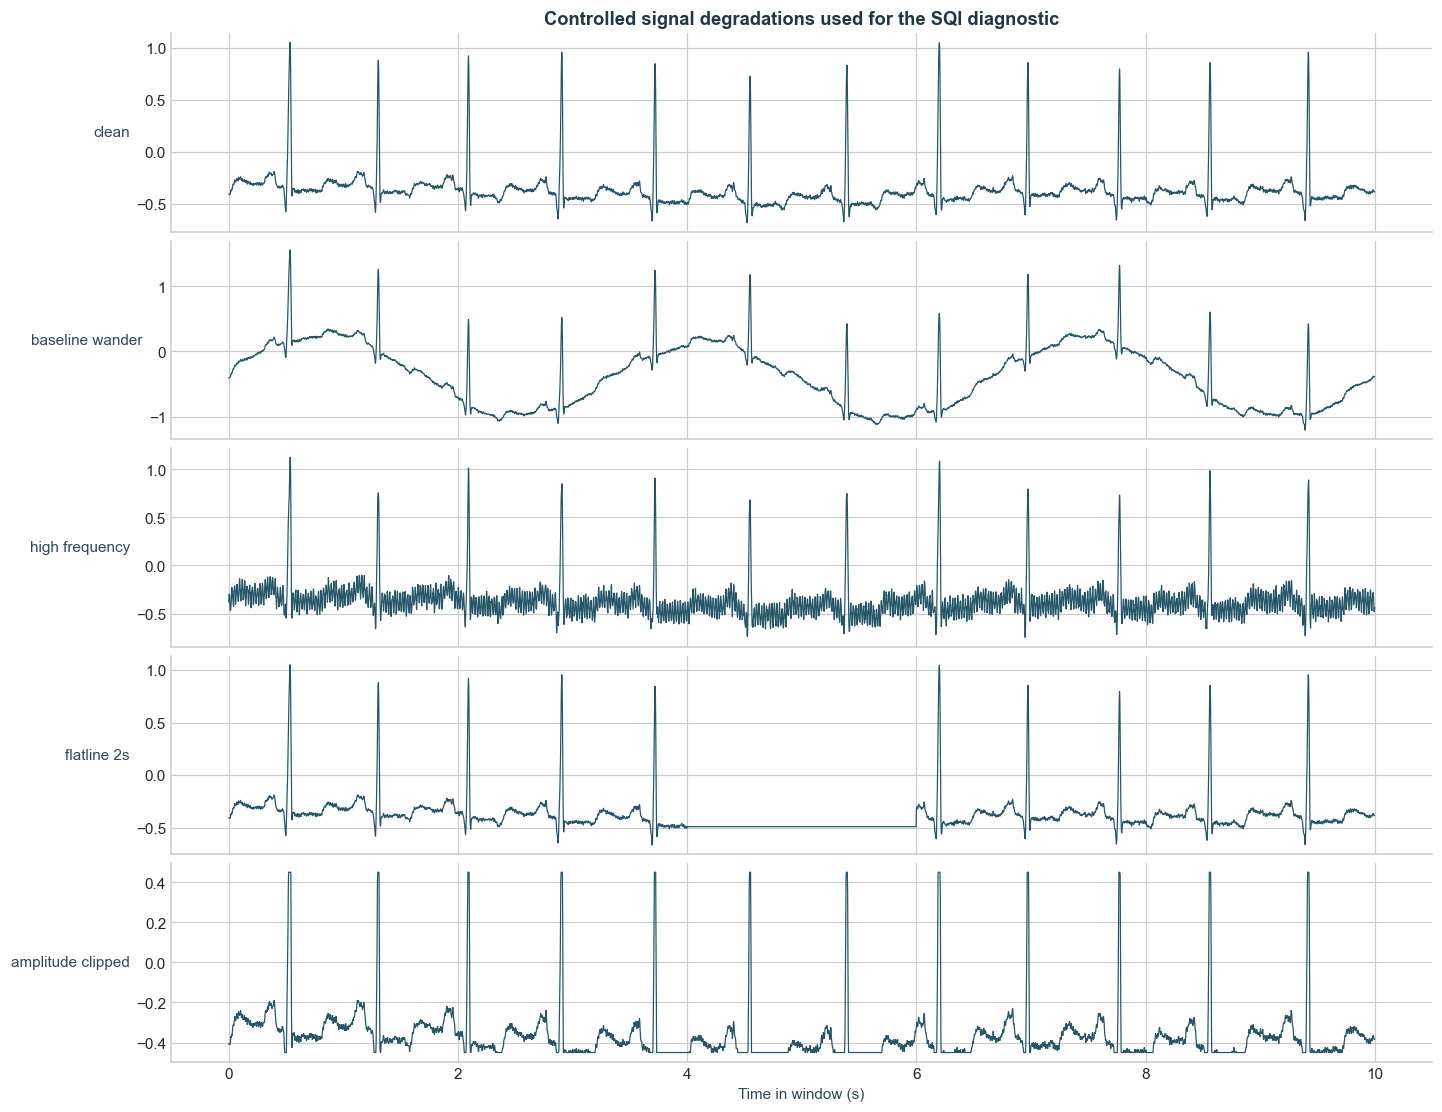

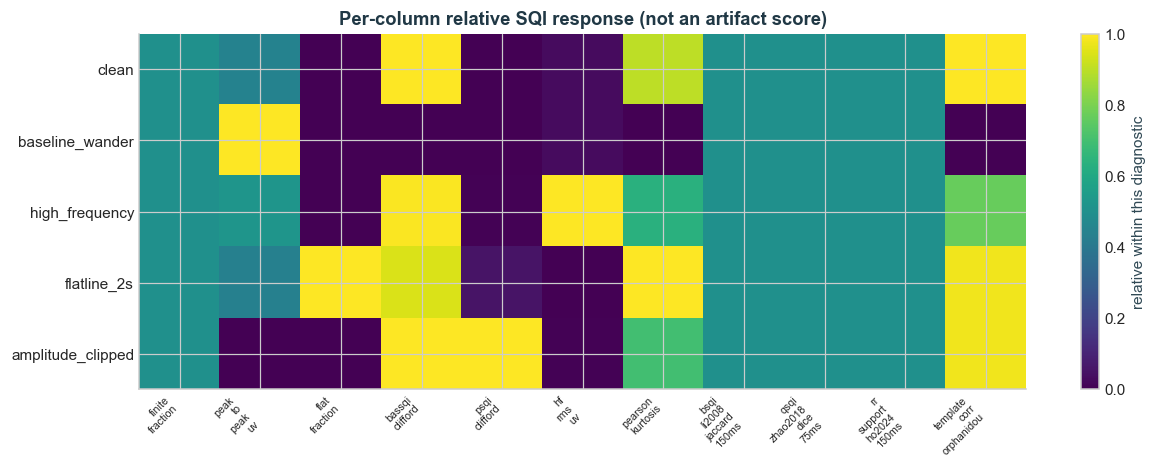

In [6]:
fig, axes = plt.subplots(len(variants), 1, figsize=(13, 10), sharex=True, constrained_layout=True)
for ax, (name, signal) in zip(axes, variants.items()):
    ax.plot(local_t, signal, lw=.8, color="#245668")
    ax.set_ylabel(name.replace("_", " "), rotation=0, ha="right", va="center")
axes[0].set_title("Controlled signal degradations used for the SQI diagnostic")
axes[-1].set_xlabel("Time in window (s)")
plt.show()

matrix = degradation[selected_metrics].copy()
normalized = matrix.copy()
for column in matrix:
    values = matrix[column].to_numpy(float)
    finite = np.isfinite(values)
    if finite.any() and np.ptp(values[finite]) > 0:
        normalized.loc[finite, column] = (values[finite] - values[finite].min()) / np.ptp(values[finite])
    else:
        normalized.loc[finite, column] = .5
fig, ax = plt.subplots(figsize=(13, 4.2))
image = ax.imshow(normalized.to_numpy(float), aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(len(selected_metrics)), [name.replace("_", "\n") for name in selected_metrics], rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(normalized)), normalized.index)
ax.set_title("Per-column relative SQI response (not an artifact score)")
fig.colorbar(image, ax=ax, label="relative within this diagnostic")
plt.show()

## 6. Case study — controlled NSTDB electrode-motion noise

The prior [signal-quality implementation audit](../../docs/21_SIGNAL_QUALITY_BRANCH_V0.md)
evaluated 12 electrode-motion windows from NSTDB records 118/119 at
+24 through −6 dB. Because noise is added at known SNR levels, this is a
useful monotonic-response case. It is still **not** a manually labelled
artifact-classification benchmark.

The earlier run found strong positive rank correlation with improving
SNR for basSQI, qSQI, and bSQI, while amplitude RMS and high-frequency
RMS increased as SNR worsened. Menon's Fourier score was nearly
non-monotonic, which is exactly why a multi-feature context vector is
retained instead of a universal hard veto.

The conceptual evidence review, [*Signal Quality as Context in ECG
Diagnostic Fusion*](../../reports/Signal_Quality_as_Context_Evidence_Review.pdf),
concluded that quality supplied beside physiology has direct precedent,
but this exact quality-plus-ECG seizure formulation remains unvalidated.
The case cell therefore visualizes response and never reports accuracy,
sensitivity, specificity, or an artifact label.

Useful method precedents include Zhao and Zhang's detector-agreement
SQI ([DOI 10.3389/fphys.2018.00727](https://doi.org/10.3389/fphys.2018.00727))
and Li, Mark, and Clifford's bSQI framework
([open article](https://pmc.ncbi.nlm.nih.gov/articles/PMC2259026/)).

#### Code walkthrough — replay the prior NSTDB electrode-motion case study

        **Why this cell exists.** Synthetic examples are useful, but the repository also contains a controlled benchmark with real electrode-motion noise mixed into MIT–BIH ECG at known SNR levels.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Evidence load | Reads the saved window-level features and Spearman rank diagnostic from the prior NSTDB run. | The notebook cites empirical repository outputs rather than retyping summary numbers. |
| 2 | Scope filter | Keeps the 12 electrode-motion windows from records 118/119 and sorts by SNR. | Clean-source rows and unrelated conditions do not enter the case plot. |
| 3 | Correlation table | Shows how each SQI ranks with improving SNR. | Positive and negative directions are both meaningful and must not be hidden. |
| 4 | SNR trajectories | Plots selected features separately for the two source records. | A pooled correlation can be checked against record-level paths. |
| 5 | Rank bar chart | Colors positive versus negative rho and marks zero. | The successful-run screenshot summarizes monotonicity without implying accuracy. |
| 6 | Assertions | Checks 12 windows and the previously documented basSQI/rms directions. | A stale or wrong evidence file fails visibly. |

        **Evidence that the cell ran correctly**

        - Twelve noisy windows are reported across +24 to −6 dB.
- basSQI has strong positive rho with improving SNR, while RMS/HF RMS have negative rho.
- Menon is visibly near non-monotonic and is not promoted to a veto.

        **If that evidence is absent, investigate**

        - Wrong evidence directory or columns.
- Treating SNR rank correlation as artifact-classifier sensitivity/specificity.
- Transferring a threshold from NSTDB to a different patient/device.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

,evaluable_windows,spearman_with_snr_db
feature,,
bassqi_clifford,12,0.975320
qsqi_zhao2018_dice_75ms,12,0.828571
bsqi_li2008_jaccard_150ms,12,0.788644
rr_support_ho2024_150ms,12,0.589706
template_corr_orphanidou,12,0.522998
pearson_kurtosis,12,0.339242
menon_fourier_score,12,-0.127216
psqi_clifford,12,-0.735024
hf_rms_uv,12,-0.848104


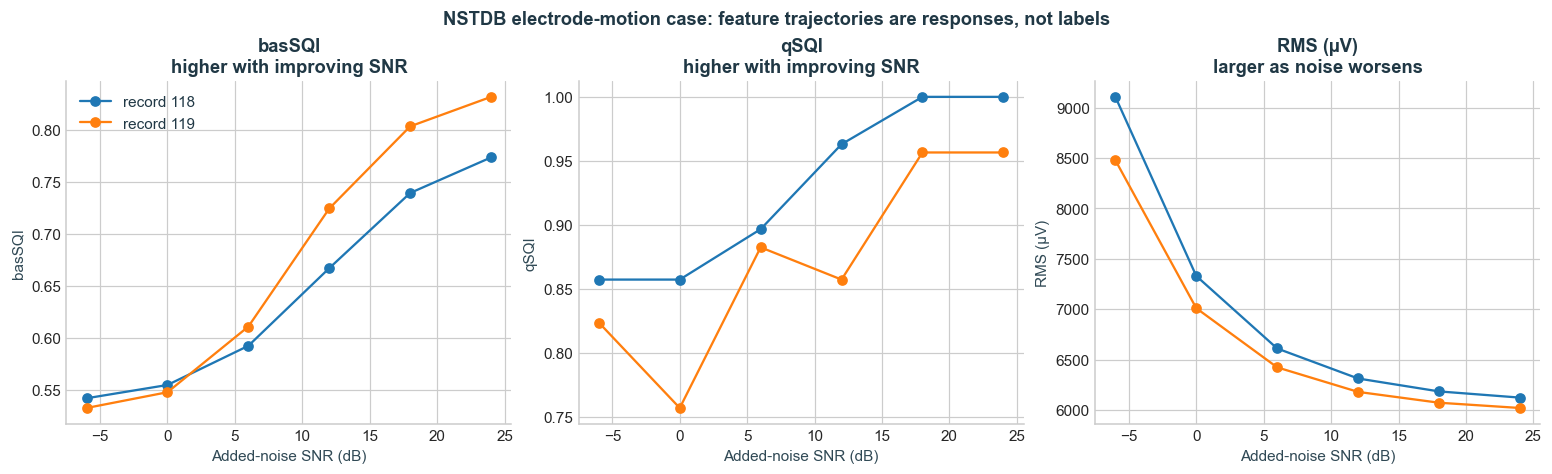

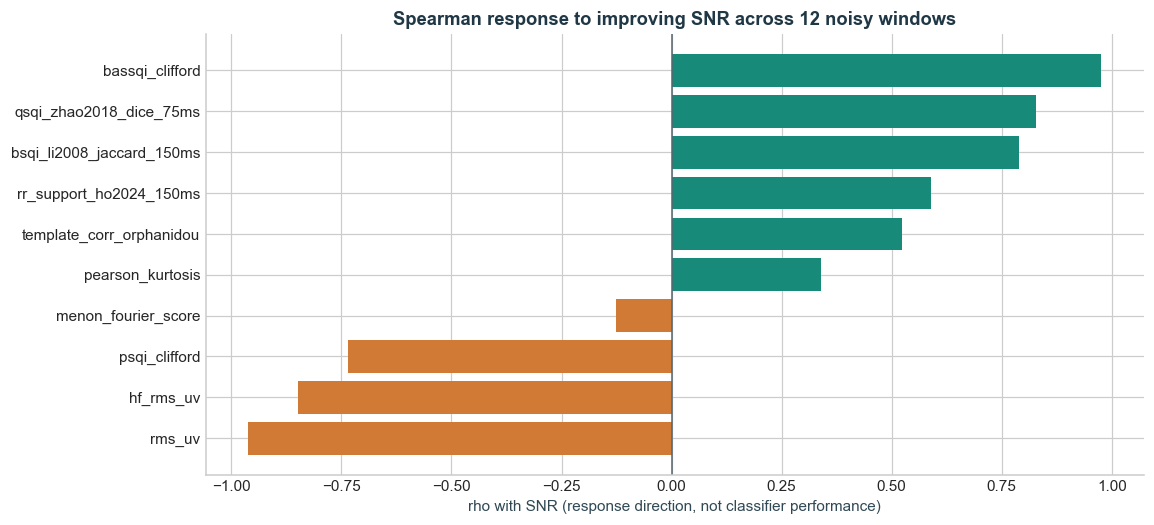

PASS — NSTDB case evidence loaded: 12 electrode-motion windows, no label fitted.


In [7]:
NSTDB_CASE = PROJECT / "outputs" / "signal_quality_nstdb_v0"
feature_path = NSTDB_CASE / "window_features.csv"
rank_path = NSTDB_CASE / "snr_rank_diagnostics.csv"
assert feature_path.is_file(), feature_path
assert rank_path.is_file(), rank_path

nstdb_features = pd.read_csv(feature_path)
nstdb_rank = pd.read_csv(rank_path).set_index("feature")
nstdb_noisy = nstdb_features.loc[
    nstdb_features["condition"].eq("electrode_motion")
].copy()
nstdb_noisy["snr_db"] = pd.to_numeric(nstdb_noisy["snr_db"], errors="raise")
nstdb_noisy = nstdb_noisy.sort_values(["source_record", "snr_db"])

display(nstdb_rank.sort_values("spearman_with_snr_db", ascending=False))
assert len(nstdb_noisy) == 12
assert nstdb_rank.loc["bassqi_clifford", "spearman_with_snr_db"] > 0.95
assert nstdb_rank.loc["rms_uv", "spearman_with_snr_db"] < -0.95

trajectory_metrics = [
    ("bassqi_clifford", "basSQI", "higher with improving SNR"),
    ("qsqi_zhao2018_dice_75ms", "qSQI", "higher with improving SNR"),
    ("rms_uv", "RMS (µV)", "larger as noise worsens"),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
for ax, (column, label, interpretation) in zip(axes, trajectory_metrics):
    for source_record, group in nstdb_noisy.groupby("source_record"):
        ax.plot(group["snr_db"], group[column], marker="o", lw=1.5, label=f"record {source_record}")
    ax.set(title=f"{label}\n{interpretation}", xlabel="Added-noise SNR (dB)", ylabel=label)
axes[0].legend()
fig.suptitle("NSTDB electrode-motion case: feature trajectories are responses, not labels", fontweight="bold")
plt.show()

rank_plot = nstdb_rank.sort_values("spearman_with_snr_db")
colors = np.where(rank_plot["spearman_with_snr_db"] >= 0, "#188a7a", "#d17a35")
fig, ax = plt.subplots(figsize=(11, 5.2))
ax.barh(rank_plot.index, rank_plot["spearman_with_snr_db"], color=colors)
ax.axvline(0, color="#56666d", lw=1)
ax.set(
    title="Spearman response to improving SNR across 12 noisy windows",
    xlabel="rho with SNR (response direction, not classifier performance)",
)
plt.show()
print("PASS — NSTDB case evidence loaded: 12 electrode-motion windows, no label fitted.")

### How to read the successful-run screenshots

- Moving right on the three trajectory panels means **less severe added
  noise**. basSQI and qSQI generally rise; RMS falls. The two record
  traces need not overlap because underlying ECG amplitude/morphology
  differ.
- In the horizontal bar chart, positive rho means a feature tends to
  increase with improving SNR; negative rho means it tends to decrease.
  Direction is not "good" versus "bad."
- A correlation near zero, such as the recorded Menon result, means this
  particular feature did not rank these 12 windows monotonically. It
  should remain a comparator, not be forced into a hard threshold.
- Correct execution is the expected table, two figures, 12-window
  assertion, and final PASS sentence—not a clean/artifact prediction.

## 7. Causal trailing 10-second quality windows across the recording

#### Code walkthrough — declare units and construct every SQI prerequisite

        **Why this cell exists.** Amplitude SQIs, cross-lead agreement, detector agreement, and baseline estimates are meaningless if their units and event sources are implicit.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Header audit | Reads WFDB channel names/units and requires MLII to be stored in mV. | The following µV conversion must match metadata. |
| 2 | Unit/mains constants | Sets 1000 µV per input unit and an explicit 60-Hz demo assumption. | Amplitude and powerline features need physical metadata. |
| 3 | Second lead | Loads synchronized V5 with matching rate and length. | Cross-lead iSQI compares events; it does not average waveforms. |
| 4 | Detector pair | Creates NeuroKit and Zhai event arrays on MLII and NeuroKit events on V5. | bSQI/qSQI/iSQI require named, independent inputs. |
| 5 | QRS onsets | Runs prominence delineation and retains finite integer onset samples. | Galeotti baseline anchors require QRS timing. |
| 6 | Count print | Reports prerequisite event availability. | Missing inputs are visible before the SQI table. |

        **Evidence that the cell ran correctly**

        - Header units print MLII/V5 as mV and all four event counts are positive.
- The synchronization assertions pass.

        **If that evidence is absent, investigate**

        - A dataset stored in V, µV, or ADC counts—change the conversion explicitly.
- Wrong mains-region metadata.
- Unsynchronized lead segments or missing QRS onset landmarks.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

,window_start_sample,window_end_sample_exclusive,finite_fraction,finite_fraction__available,finite_fraction__reason,absmax_uv,absmax_uv__available,absmax_uv__reason,peak_to_peak_uv,peak_to_peak_uv__available,peak_to_peak_uv__reason,rms_uv,rms_uv__available,rms_uv__reason,saturation_fraction_langley2011,saturation_fraction_langley2011__available,saturation_fraction_langley2011__reason,longest_saturation_run_s_langley2011,longest_saturation_run_s_langley2011__available,longest_saturation_run_s_langley2011__reason,flat_fraction,flat_fraction__available,flat_fraction__reason,longest_flat_run_s,longest_flat_run_s__available,longest_flat_run_s__reason,rail_fraction,rail_fraction__available,rail_fraction__reason,longest_rail_run_s,longest_rail_run_s__available,longest_rail_run_s__reason,bassqi_clifford,bassqi_clifford__available,bassqi_clifford__reason,psqi_clifford,psqi_clifford__available,psqi_clifford__reason,sdr_li2008,sdr_li2008__available,sdr_li2008__reason,ssqi_li2008_binary,ssqi_li2008_binary__available,ssqi_li2008_binary__reason,skewness,skewness__available,skewness__reason,pearson_kurtosis,pearson_kurtosis__available,pearson_kurtosis__reason,ksqi_li2008_binary,ksqi_li2008_binary__available,ksqi_li2008_binary__reason,hf_rms_uv,hf_rms_uv__available,hf_rms_uv__reason,hf_contaminated_fraction,hf_contaminated_fraction__available,hf_contaminated_fraction__reason,bsqi_li2008_jaccard_150ms,bsqi_li2008_jaccard_150ms__available,bsqi_li2008_jaccard_150ms__reason,qsqi_zhao2018_dice_75ms,qsqi_zhao2018_dice_75ms__available,qsqi_zhao2018_dice_75ms__reason,rr_support_ho2024_150ms,rr_support_ho2024_150ms__available,rr_support_ho2024_150ms__reason,template_corr_orphanidou,template_corr_orphanidou__available,template_corr_orphanidou__reason,menon_fourier_score,menon_fourier_score__available,menon_fourier_score__reason,isqi_li2008_max_jaccard_150ms,isqi_li2008_max_jaccard_150ms__available,isqi_li2008_max_jaccard_150ms__reason,isqi_primary_unmatched_fraction_at_best_lead,isqi_primary_unmatched_fraction_at_best_lead__available,isqi_primary_unmatched_fraction_at_best_lead__reason,isqi_other_unmatched_fraction_at_best_lead,isqi_other_unmatched_fraction_at_best_lead__available,isqi_other_unmatched_fraction_at_best_lead__reason,baseline_rms_galeotti,baseline_rms_galeotti__available,baseline_rms_galeotti__reason,mains_rms_galeotti,mains_rms_galeotti__available,mains_rms_galeotti__reason,residual_rms_galeotti,residual_rms_galeotti__available,residual_rms_galeotti__reason,dominant_beat_excluded_fraction,dominant_beat_excluded_fraction__available,dominant_beat_excluded_fraction__reason,window_end_s
0,0,3600,1.0,True,calculated,960.0,True,calculated,1605.0,True,calculated,362.389466,True,calculated,0.0,True,calculated,0.0,True,calculated,0.0,True,calculated,0.0,True,calculated,None,False,adc_rail_metadata_missing,None,False,adc_rail_metadata_missing,0.985055,True,calculated,0.494815,True,calculated,0.447550,True,calculated,0.0,True,published_0.5_to_0.8_rule,4.934706,True,calculated,31.511916,True,calculated,1.0,True,published_pearson_kurtosis_gt_5_rule,20.409333,True,calculated,None,False,device_specific_hf_threshold_not_supplied,1.0,True,calculated,1.0,True,calculated,1.0,True,calculated,0.985480,True,insufficient_complete_nonconstant_beats,6.961900e+14,True,calculated,0.923077,True,calculated,0.076923,True,calculated,0.0,True,calculated,414.128739,True,calculated,5.980178,True,calculated,None,False,paper_does_not_freeze_grouping_rule_external_b...,None,False,paper_does_not_freeze_grouping_rule_external_b...,10.0
1,1800,5400,1.0,True,calculated,945.0,True,calculated,1530.0,True,calculated,360.373408,True,calculated,0.0,True,calculated,0.0,True,calculated,0.0,True,calculated,0.0,True,calculated,None,False,adc_rail_metadata_missing,None,False,adc_rail_metadata_missing,0.978976,True,calculated,0.507222,True,calculated,0.451171,True,calculated,0.0,True,published_0.5_to_0.8_rule,4.954868,True,calculated,31.620410,True,calculated,1.0,True,published_pearson_ku

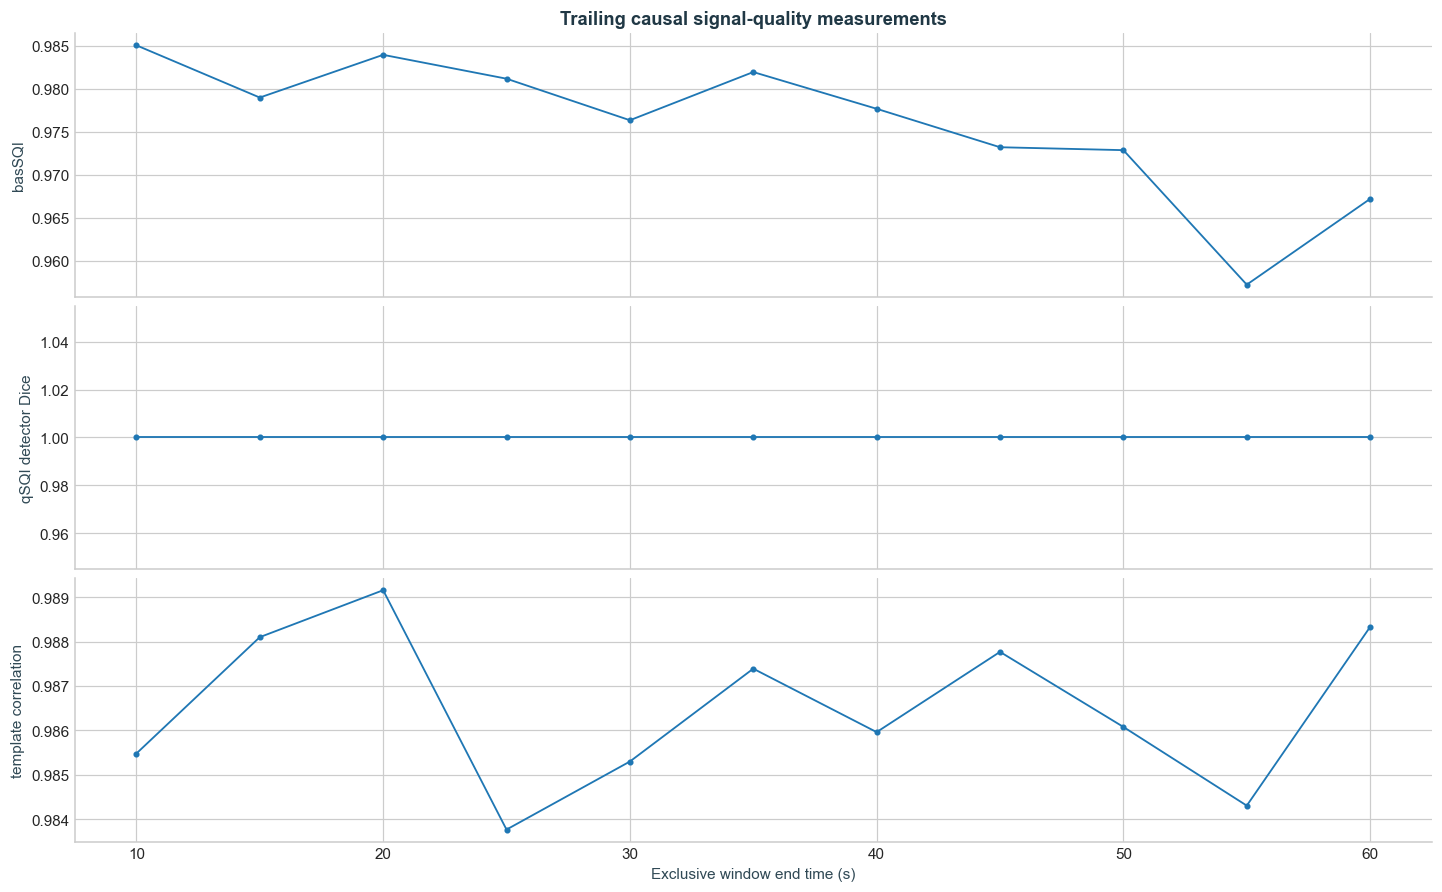

In [8]:
from ecg_cascade.signal_quality import extract_trailing_signal_quality_windows

quality_series = extract_trailing_signal_quality_windows(
    ecg, fs,
    uv_per_input_unit=UV_PER_INPUT_UNIT,
    window_s=10.0,
    step_s=5.0,
    primary_peak_samples=primary_peaks,
    secondary_peak_samples=secondary_peaks,
    qrs_onset_samples=qrs_onsets,
    other_lead_peak_samples=[other_lead_peaks],
    mains_frequency_hz=MAINS_FREQUENCY_HZ,
)
trailing = quality_series.to_frame()
trailing["window_end_s"] = trailing["window_end_sample_exclusive"] / fs
display(trailing.head())

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True, constrained_layout=True)
plotted = [
    ("bassqi_clifford", "basSQI"),
    ("qsqi_zhao2018_dice_75ms", "qSQI detector Dice"),
    ("template_corr_orphanidou", "template correlation"),
]
for ax, (column, label) in zip(axes, plotted):
    ax.plot(trailing["window_end_s"], trailing[column], marker="o", ms=3, lw=1.2)
    ax.set_ylabel(label)
axes[0].set_title("Trailing causal signal-quality measurements")
axes[-1].set_xlabel("Exclusive window end time (s)")
plt.show()

## 8. Export measurements, availability, reasons, and configuration

#### Code walkthrough — export SQI values together with availability and reasons

        **Why this cell exists.** Downstream users need to distinguish 'feature is low' from 'feature could not be calculated'.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Single-window export | Writes values, booleans, and reasons in one indexed CSV. | The complete conditional schema survives outside the notebook. |
| 2 | Diagnostic export | Writes controlled-degradation and trailing-window tables. | Static and temporal demonstrations remain reproducible. |
| 3 | Parameter export | Saves the extractor's recorded parameters as JSON. | Units, frequency, and algorithm choices travel with measurements. |
| 4 | Directory listing | Prints filenames and byte sizes. | Zero-byte or missing artifacts are immediately visible. |

        **Evidence that the cell ran correctly**

        - Three CSV files and one JSON file are listed with positive byte sizes.

        **If that evidence is absent, investigate**

        - Dropping the availability/reason columns.
- Writing display-normalized heatmap values instead of raw SQIs.
- An output directory from a different branch.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [9]:
quality_table.to_csv(OUTPUT_DIR / "single_window_quality_with_availability.csv")
degradation.to_csv(OUTPUT_DIR / "controlled_degradation_quality.csv")
trailing.to_csv(OUTPUT_DIR / "trailing_signal_quality_windows.csv", index=False)
(OUTPUT_DIR / "single_window_parameters.json").write_text(
    json.dumps(clean_quality.parameters, indent=2), encoding="utf-8"
)
print("Exported files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    print(" -", path.name, path.stat().st_size, "bytes")

Exported files:
 - controlled_degradation_quality.csv 1923 bytes
 - single_window_parameters.json 1076 bytes
 - single_window_quality_with_availability.csv 1728 bytes
 - source_manifest.json 810 bytes
 - trailing_signal_quality_windows.csv 14023 bytes


## 9. Notebook-level acceptance checks and limits

#### Code walkthrough — enforce SQI availability, response, causality, and no-classifier scope

        **Why this cell exists.** The branch is intentionally a measurement vector; the acceptance cell makes that scientific boundary executable.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Core availability | Requires finite fraction, bSQI, qSQI, and cross-lead iSQI in the fully supplied demo. | All major prerequisite paths must execute. |
| 2 | Known response | Requires the inserted flatline to increase flat fraction. | At least one controlled mechanism is checked directionally. |
| 3 | Trailing coverage | Requires nonempty aligned trailing output. | The causal time-series path must run. |
| 4 | Forbidden schema | Rejects artifact/clean/seizure labels or probabilities. | No unvalidated classifier can masquerade as preprocessing. |

        **Evidence that the cell ran correctly**

        - The cell ends with `PASS — signal-quality measurements executed without inventing an artifact classifier.`

        **If that evidence is absent, investigate**

        - Missing prerequisites before loosening an availability assertion.
- Incorrect variant construction if flatline response fails.
- Any newly introduced hard decision field.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [10]:
assert clean_quality.available["finite_fraction"]
assert clean_quality.available["bsqi_li2008_jaccard_150ms"]
assert clean_quality.available["qsqi_zhao2018_dice_75ms"]
assert clean_quality.available["isqi_li2008_max_jaccard_150ms"]
assert comparison_results["flatline_2s"].values["flat_fraction"] > clean_quality.values["flat_fraction"]
assert len(trailing) == len(quality_series.windows) > 0
forbidden = {"artifact_label", "artifact_probability", "clean_label", "seizure_probability"}
assert not forbidden.intersection(clean_quality.values)
print("PASS — signal-quality measurements executed without inventing an artifact classifier.")

PASS — signal-quality measurements executed without inventing an artifact classifier.


### Interpretation limits

- Synthetic degradation response is not artifact-classifier accuracy.
- Device-specific rails and high-frequency thresholds remain unavailable
  unless the caller supplies them.
- SQI thresholds cannot be transferred from one dataset/device without
  patient-wise calibration and manually labelled artifact windows.
- Detector agreement can fail on clean pathological rhythms and can agree
  on a shared error; it is context, not truth.
- BUT-QDB or equivalent labelled data remains necessary before fitting and
  evaluating an artifact classifier.

## Exact implementation appendix

To make the executed notebook a durable audit artifact, this section
embeds the **complete source text** of the modules used above and records
a SHA-256 digest for each file. The algorithms are imported from these
tested modules; they are not rewritten in a second, drifting notebook copy.

#### Code walkthrough — embed exact implementation source and cryptographic hashes

        **Why this cell exists.** A notebook can otherwise become an attractive but stale copy of production code; this cell records precisely what implementation was executed.

        | Order | Code chunk | What executes | Why it is here |
        |---:|---|---|---|
        | 1 | Source list | Freezes the branch modules and scripts included in the appendix. | The reader can audit the implementation boundary. |
| 2 | File loop | Reads every file as UTF-8, counts lines, and calculates SHA-256. | A one-character source change produces a different digest. |
| 3 | Rendered source | Displays the complete Python text in the executed notebook. | Every internal line remains reviewable without opening a second application. |
| 4 | Manifest export | Writes `source_manifest.json` and displays its table. | Automated checks can compare filenames, line counts, and hashes later. |

        **Evidence that the cell ran correctly**

        - Each expected module appears as a rendered code block with a 64-character SHA-256 digest.
- The final table contains one row per requested source file and positive line counts.
- `source_manifest.json` is saved in the branch output directory.

        **If that evidence is absent, investigate**

        - A source module that moved or is missing.
- An unexpected project root, which would hash the wrong files.
- Notebook size limits if a front end refuses to render the complete appendix.

        The code cell immediately below is the executable source of these outputs.
        Read the chunks in table order; statements inside a loop or function belong
        to the chunk that introduces that block.

In [11]:
SOURCE_FILES = ['src/ecg_cascade/signal_quality.py', 'src/ecg_cascade/rr_reliability_context.py', 'src/ecg_cascade/peaks.py', 'src/ecg_cascade/zhai.py', 'scripts/validate_signal_quality_nstdb.py']
source_manifest = []
for relative in SOURCE_FILES:
    path = PROJECT / relative
    text = path.read_text(encoding="utf-8")
    digest = hashlib.sha256(text.encode("utf-8")).hexdigest()
    source_manifest.append({"file": relative, "sha256": digest, "lines": len(text.splitlines())})
    display(Markdown(f"### `{relative}`  \nSHA-256: `{digest}` · {len(text.splitlines())} lines"))
    display(Code(text, language="python"))

source_manifest_path = OUTPUT_DIR / "source_manifest.json"
source_manifest_path.write_text(json.dumps(source_manifest, indent=2), encoding="utf-8")
display(pd.DataFrame(source_manifest))
print("Saved:", source_manifest_path)

### `src/ecg_cascade/signal_quality.py`  
SHA-256: `1d9fcd801c70e26328f87fac0a973938396a6f41f61035396cd11a925d967eb1` · 1140 lines

"""Paper-traceable ECG signal-quality measurements for one analysis window.

The module intentionally returns measurements and availability state, not a
binary clean/artifact decision.  Thresholds that were tuned to a particular
device are accepted only as explicit inputs.  Likewise, ADC-rail, QRS-onset,
and beat-group features remain unavailable when their prerequisites are not
supplied.

The default analysis unit is one 10-second ECG window.  Callers own the window
alignment (centred, trailing/causal, or disjoint) and must record that choice.
"""

from __future__ import annotations

from dataclasses import dataclass, field
from typing import Any, Sequence

import numpy as np
from scipy import interpolate, ndimage, signal as scipy_signal


@dataclass(frozen=True)
class SignalQualityWindowResult:
    """Continuous feature values plus per-feature computability metadata."""

    values: dict[str, float]
    available: dict[str, bool]
    reasons: dict[str, str]
    parameters: dict[str, Any]
    intermediates: dict[str, np.ndarray] = field(default_factory=dict, repr=False)

    def to_record(self) -> dict[str, object]:
        """Return a flat, serialization-friendly feature/validity record."""

        record: dict[str, object] = {}
        for name, value in self.values.items():
            record[name] = float(value) if np.isfinite(value) else None
            record[f"{name}__available"] = bool(self.available[name])
            record[f"{name}__reason"] = self.reasons[name]
        return record


@dataclass(frozen=True)
class SignalQualitySeriesResult:
    """Ordered trailing-window results with explicit sample boundaries."""

    window_start_samples: np.ndarray
    window_end_samples_exclusive: np.ndarray
    windows: tuple[SignalQualityWindowResult, ...]

    def to_frame(self):
        """Return one flat row per window (pandas imported only on demand)."""

        import pandas as pd

        rows: list[dict[str, object]] = []
        for first, last, result in zip(
            self.window_start_samples,
            self.window_end_samples_exclusive,
            self.windows,
            strict=True,
        ):
            row = {
                "window_start_sample": int(first),
                "window_end_sample_exclusive": int(last),
            }
            row.update(result.to_record())
            rows.append(row)
        return pd.DataFrame(rows)


@dataclass(frozen=True)
class HoRRSupport:
    """Ho-style primary-beat and primary-RR endpoint support."""

    primary_supported: np.ndarray
    rr_supported: np.ndarray
    secondary_count_near_primary: np.ndarray

    @property
    def supported_rr_fraction(self) -> float:
        if self.rr_supported.size == 0:
            return float("nan")
        return float(np.mean(self.rr_supported))


@dataclass(frozen=True)
class GaleottiBaselineResult:
    rms: float
    estimate: np.ndarray
    anchor_samples: np.ndarray
    anchor_values: np.ndarray


@dataclass(frozen=True)
class GaleottiPowerlineResult:
    rms: float
    estimate: np.ndarray


@dataclass(frozen=True)
class GaleottiResidualResult:
    rms: float
    excluded_fraction: float
    used_beat_count: int
    complete_beat_count: int


@dataclass(frozen=True)
class MenonTemplateResult:
    template: np.ndarray
    coefficients: np.ndarray
    converged: bool
    beats_used: int
    final_relative_coefficient_change: float


class _FeatureBuilder:
    def __init__(self) -> None:
        self.values: dict[str, float] = {}
        self.available: dict[str, bool] = {}
        self.reasons: dict[str, str] = {}

    def add(
        self,
        name: str,
        value: float | None = None,
        *,
        reason: str = "calculated",
    ) -> None:
        finite = value is not None and np.isfinite(value)
        self.values[name] = float(value) if finite else float("nan")
        self.available[name] = bool(finite)
        if not finite and reason == "calculated":
            reason = "numerical_result_un

### `src/ecg_cascade/rr_reliability_context.py`  
SHA-256: `291cdcc6d8981c5bc6a403497f4320aa7a258e1d86f7d58461bbb74e092f7ef0` · 274 lines

"""UNSW-owned RR timestamps with NeuroKit reliability context.

This module never substitutes a NeuroKit timestamp into the RR sequence.
It implements a project adaptation of the primary/secondary comparison
structure described by Ho et al. and exports the qSQI Dice form
``2 * matches / (primary_count + secondary_count)``.

The score formula is published; applying it to UNSW and NeuroKit in centered
and trailing 10-second moving windows is an explicitly labelled adaptation.
Li's bSQI is the different Jaccard form and is implemented under its own name
in :mod:`ecg_cascade.signal_quality`.
"""

from __future__ import annotations

from dataclasses import dataclass

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class RRContextResult:
    """Unchanged UNSW timestamps plus beat/RR/window reliability context."""

    unsw_samples: np.ndarray
    neurokit_samples: np.ndarray
    events: pd.DataFrame
    rr_intervals: pd.DataFrame
    support_tolerance_ms: float
    agreement_window_s: float

    def summary(self) -> dict[str, object]:
        return {
            "unsw_event_count": int(self.unsw_samples.size),
            "neurokit_event_count": int(self.neurokit_samples.size),
            "support_tolerance_ms": float(self.support_tolerance_ms),
            "agreement_window_s": float(self.agreement_window_s),
            "supported_beat_fraction": (
                float(self.events["unsw_supported"].mean())
                if not self.events.empty
                else None
            ),
            "supported_rr_fraction": (
                float(self.rr_intervals["rr_supported"].mean())
                if not self.rr_intervals.empty
                else None
            ),
            "timestamp_owner": "unsw_initial_unchanged",
            "neurokit_role": "context_only_no_timestamp_substitution",
        }


def build_unsw_neurokit_rr_context(
    unsw_samples: np.ndarray,
    neurokit_samples: np.ndarray,
    *,
    sampling_rate_hz: float,
    support_tolerance_ms: float,
    agreement_window_s: float = 10.0,
) -> RRContextResult:
    """Calculate support fields while preserving every UNSW timestamp.

    Per-beat support follows the Ho structure but uses the caller-selected
    tolerance.  The extra requirement of exactly two NeuroKit events in the
    tolerance-expanded RR interval is a project rule, not Ho's published
    endpoint-only RR definition.  The exact 150-ms endpoint-only feature is
    ``rr_support_ho2024`` in :mod:`ecg_cascade.signal_quality`.

    The centered 10-second agreement score is offline context.  The trailing
    score uses only events at or before the current UNSW event and is suitable
    for a causal architecture.  Neither score is a calibrated probability.
    """

    if sampling_rate_hz <= 0:
        raise ValueError("sampling_rate_hz must be positive")
    if support_tolerance_ms <= 0:
        raise ValueError("support_tolerance_ms must be positive")
    if agreement_window_s <= 0:
        raise ValueError("agreement_window_s must be positive")
    unsw = _strictly_increasing(unsw_samples, "unsw_samples")
    neurokit = _strictly_increasing(neurokit_samples, "neurokit_samples")
    tolerance = max(
        1,
        int(np.rint(support_tolerance_ms * sampling_rate_hz / 1000.0)),
    )
    window = max(1, int(np.rint(agreement_window_s * sampling_rate_hz)))
    half_window = window // 2

    event_rows: list[dict[str, object]] = []
    for event_index, primary_sample in enumerate(unsw):
        left = int(
            np.searchsorted(neurokit, primary_sample - tolerance, side="left")
        )
        right = int(
            np.searchsorted(neurokit, primary_sample + tolerance, side="right")
        )
        nearby = neurokit[left:right]
        if nearby.size:
            nearest = int(nearby[np.argmin(np.abs(nearby - primary_sample))])
            offset_ms = (nearest - int(primary_sample)) * 1000.0 / sampling_rate_hz
        else:
            nearest = pd.NA
          

### `src/ecg_cascade/peaks.py`  
SHA-256: `5105c5d19bf5c421d5c068312f243dc02dc91ea9cdc4e8d2e0a6cd96aed26207` · 446 lines

...

"""Paper-traceable reimplementation of Zhai et al. (2023).

The implementation in this module is an independent detector/localizer.  It
does not take NeuroKit or UNSW candidates as inputs and it does not relocate a
candidate to the largest positive ECG sample.  This is important: combining a
NeuroKit candidate generator with only the final Zhai cross-correlation step
would be a new, unvalidated hybrid rather than the published pipeline.

Reference
---------
D. Zhai, X. Bao, X. Long, T. Ru, and G. Zhou, "Precise detection and
localization of R-peaks from ECG signals," Mathematical Biosciences and
Engineering, 20(11), 19191--19208, 2023. doi:10.3934/mbe.2023848.

No official author source code was located.  Consequently, details that the
paper leaves ambiguous are exposed in ``parameters`` and are covered by unit
tests instead of being presented as author code.
"""

from __future__ import annotations

from dataclasses import dataclass

import numpy as np
from scipy import signal as scipy_signal

from .peaks import DetectorRun, orient_signal


@dataclass(frozen=True)
class ZhaiDetection:
    """Full intermediate state of one Zhai detector run."""

    detector: DetectorRun
    squared_signal: np.ndarray
    qrs_envelope: np.ndarray
    dynamic_threshold: np.ndarray
    qrs_mask: np.ndarray
    qrs_windows: np.ndarray
    template: np.ndarray
    template_center_sample: int | None
    template_source_window_index: int | None
    correlation_signal: np.ndarray
    correlation_peak_values: np.ndarray

    @property
    def peak_samples(self) -> np.ndarray:
        return self.detector.peak_samples

    def summary(self) -> dict[str, object]:
        payload = self.detector.summary()
        payload.update(
            {
                "qrs_window_count": int(self.qrs_windows.shape[0]),
                "template_sample_count": int(self.template.size),
                "template_center_sample": self.template_center_sample,
                "template_source_window_index": self.template_source_window_index,
                "median_absolute_correlation": (
                    float(np.median(np.abs(self.correlation_peak_values)))
                    if self.correlation_peak_values.size
                    else None
                ),
            }
        )
        return payload


def detect_zhai_template(
    ecg: np.ndarray,
    sampling_rate_hz: float,
    *,
    orientation: str = "original",
) -> ZhaiDetection:
    """Run the complete Zhai 2023 detector and template localizer.

    The defaults reproduce the values reported in the paper:

    * second-order, forward--backward 5--35 Hz Butterworth band-pass;
    * squaring followed by a second-order, forward--backward 5 Hz low-pass;
    * 400-ms threshold-update blocks with a forward 2-s amplitude context;
    * QRS windows widened to at least 200 ms;
    * one 120-ms template selected from the first five QRS windows;
    * maximum *absolute* normalized cross-correlation in each QRS window;
    * rejection of the lower-correlation member when an RR interval is less
      than 0.4 times the current mean RR interval.

    This is an offline algorithm: ``sosfiltfilt`` and the forward 2-s context
    are non-causal.  It is appropriate for the present pre-recorded data, not
    a claim of real-time deployability.
    """

    raw = _validate_signal(ecg, sampling_rate_hz)
    oriented = orient_signal(raw, orientation)

    bandpass = scipy_signal.butter(
        2,
        [5.0, 35.0],
        btype="bandpass",
        fs=sampling_rate_hz,
        output="sos",
    )
    filtered = np.asarray(
        scipy_signal.sosfiltfilt(bandpass, oriented), dtype=np.float64
    )
    squared = filtered * filtered
    lowpass = scipy_signal.butter(
        2,
        5.0,
        btype="lowpass",
        fs=sampling_rate_hz,
        output="sos",
    )
    envelope = np.asarray(
        scipy_signal.sosfiltfilt(lowpass, squared), dtype=np.float64
    )

    threshold, initial_mask = _dynamic_qrs_thres

### `scripts/validate_signal_quality_nstdb.py`  
SHA-256: `cfcdbd583af47a63d13dbf3ebcf3877e1551df86f9230c92942c4b1a5404b172` · 237 lines

"""Validate signal-quality v0 behavior on the local MIT-BIH NSTDB copy.

This is a controlled degradation diagnostic, not artifact-classifier
validation.  NSTDB supplies known electrode-motion SNR levels and retained
beat annotations, but it does not provide the window-level labels needed to
train or calibrate the final BUT-QDB quality classifier.
"""

from __future__ import annotations

import argparse
from pathlib import Path

import numpy as np
import pandas as pd

from ecg_cascade.peaks import detect_neurokit_gradient, detect_unsw
from ecg_cascade.signal_quality import extract_signal_quality_window
from ecg_cascade.wfdb_io import load_wfdb_beat_annotations, load_wfdb_segment


PROJECT = Path(__file__).resolve().parents[1]
WORKSPACE = PROJECT.parent
DEFAULT_NSTDB = (
    WORKSPACE
    / "Datasets"
    / "mit-bih-noise-stress-test-database-1.0"
    / "mit-bih-noise-stress-test-database-1.0.0"
)
DEFAULT_MITDB = (
    WORKSPACE
    / "Datasets"
    / "mit-bih-arrhythmia-database-1.0"
    / "mit-bih-arrhythmia-database-1.0.0"
)
NOISY_RECORDS = (
    ("e24", 24),
    ("e18", 18),
    ("e12", 12),
    ("e06", 6),
    ("e00", 0),
    ("e_6", -6),
)


def _markdown_table(frame: pd.DataFrame) -> str:
    headers = [str(column) for column in frame.columns]
    lines = [
        "| " + " | ".join(headers) + " |",
        "| " + " | ".join("---" for _ in headers) + " |",
    ]
    for row in frame.itertuples(index=False, name=None):
        rendered = []
        for value in row:
            if isinstance(value, float):
                rendered.append("" if np.isnan(value) else f"{value:.6g}")
            else:
                rendered.append(str(value))
        lines.append("| " + " | ".join(rendered) + " |")
    return "\n".join(lines)


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser()
    parser.add_argument("--nstdb-root", type=Path, default=DEFAULT_NSTDB)
    parser.add_argument("--mitdb-root", type=Path, default=DEFAULT_MITDB)
    parser.add_argument(
        "--output",
        type=Path,
        default=PROJECT / "outputs" / "signal_quality_nstdb_v0",
    )
    parser.add_argument("--start-s", type=float, default=360.0)
    parser.add_argument("--duration-s", type=float, default=10.0)
    return parser.parse_args()


def _window_annotations(record: Path, start_s: float, duration_s: float, fs: float):
    first = int(np.rint(start_s * fs))
    last = first + int(np.rint(duration_s * fs))
    samples, _ = load_wfdb_beat_annotations(
        record,
        start_sample=first,
        end_sample=last,
    )
    return samples


def _measure_record(
    record: Path,
    *,
    source: str,
    condition: str,
    snr_db: float,
    start_s: float,
    duration_s: float,
) -> dict[str, object]:
    segment = load_wfdb_segment(
        record,
        channel=0,
        start_s=start_s,
        duration_s=duration_s,
    )
    fs = segment.sampling_rate_hz
    reference = _window_annotations(record, start_s, duration_s, fs)
    detector_error = ""
    try:
        primary = detect_unsw(segment.samples, fs, orientation="original").peak_samples
        secondary = detect_neurokit_gradient(
            segment.samples,
            fs,
            orientation="original",
            minimum_delay_ms=250.0,
            minimum_delay_inclusive=True,
        ).peak_samples
    except Exception as exc:
        primary = reference
        secondary = np.array([], dtype=np.int64)
        detector_error = f"{type(exc).__name__}: {exc}"
    result = extract_signal_quality_window(
        segment.samples,
        fs,
        uv_per_input_unit=1000.0,
        primary_peak_samples=primary,
        secondary_peak_samples=secondary,
    )
    row: dict[str, object] = {
        "source_record": source,
        "condition": condition,
        "snr_db": snr_db,
        "record": record.name,
        "start_s": start_s,
        "duration_s": segment.duration_s,
        "sampling_rate_hz": fs,
        "reference_beat_count":

,file,sha256,lines
0,src/ecg_cascade/signal_quality.py,1d9fcd801c70e26328f87fac0a973938396a6f41f61035...,1140
1,src/ecg_cascade/rr_reliability_context.py,291cdcc6d8981c5bc6a403497f4320aa7a258e1d86f7d5...,274
2,src/ecg_cascade/peaks.py,5105c5d19bf5c421d5c068312f243dc02dc91ea9cdc4e8...,446
3,src/ecg_cascade/zhai.py,1287f982727df2ee101ea6e35dc9f008a98bc73821372e...,444
4,scripts/validate_signal_quality_nstdb.py,cfcdbd583af47a63d13dbf3ebcf3877e1551df86f9230c...,237


Saved: C:\Users\Salam\Documents\ECGdetector\feature_extraction\outputs\standalone_notebooks\signal_quality\source_manifest.json
